In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
prob_name = "knapsack-energy"
prefix = "curve"
mse_log = pd.read_csv(f"/home/genghaoyu/OR/PTO/Rethink1.0-dev/saved_records/{prob_name}/mse/{prefix}/train_logs.csv")
spo_log = pd.read_csv(f"/home/genghaoyu/OR/PTO/Rethink1.0-dev/saved_records/{prob_name}/spo/{prefix}/train_logs.csv")

In [5]:
mse_log

,epoch,obj,loss,pred_loss,eval
0,Tr-0,597.753601,260174.609375,114737008.0,266.758270
1,Tr-1,618.732849,259285.593750,114344944.0,245.778976
2,Tr-2,635.597046,258373.593750,113942752.0,228.914856
3,Tr-3,644.686401,257435.656250,113529128.0,219.825500
4,Tr-4,652.397034,256468.125000,113102432.0,212.114792
...,...,...,...,...,...
374,Tr-374,800.214600,35319.175781,15575757.0,64.297241
375,Tr-375,800.214600,35311.628906,15572429.0,64.297241
376,Tr-376,800.214600,35304.109375,15569112.0,64.297241
377,Tr-377,800.214600,35296.621094,15565810.0,64.297241


In [4]:
spo_log

,epoch,obj,loss,pred_loss,eval
0,Tr-0,267505.125,378592.6875,114742568.0,113744.59375


In [13]:
def draw_curve(mse_log,e2e_log):
    sns.set_style("white")

    plt.figure(figsize=(8, 6))
    e2e_log = e2e_log.iloc[:378]
    x_ax = list(range(len(mse_log["eval"].values)))
    x_ax2 = list(range(len(e2e_log["eval"].values)))
    sns.lineplot(x=x_ax, y=mse_log["obj"].values, label="MSE Decision Quality")
    ax = sns.lineplot(x=x_ax, y=mse_log["pred_loss"].values/100000, label="MSE pred_loss")
    # sns.lineplot(x=x_ax2, y=e2e_log["obj"].values, label="SPO Decision Quality")
    # sns.lineplot(x=x_ax2, y=e2e_log["pred_loss"].values/100000, label="SPO pred_loss")
    plt.xlabel('Train Epochs')  
    plt.ylabel("Loss/Decision Quality")
    # plt.title("")
    # plt.ylim(0,3500)
    plt.legend()
    plt.show()
    scatter_fig = ax.get_figure()
    fig_path = f"/home/genghaoyu/OR/PTO/Rethink1.0-dev/visual/figs/curve/{prob_name}.pdf"
    plt.tight_layout()
    plt.show()
    scatter_fig.savefig(fig_path, dpi = 400)



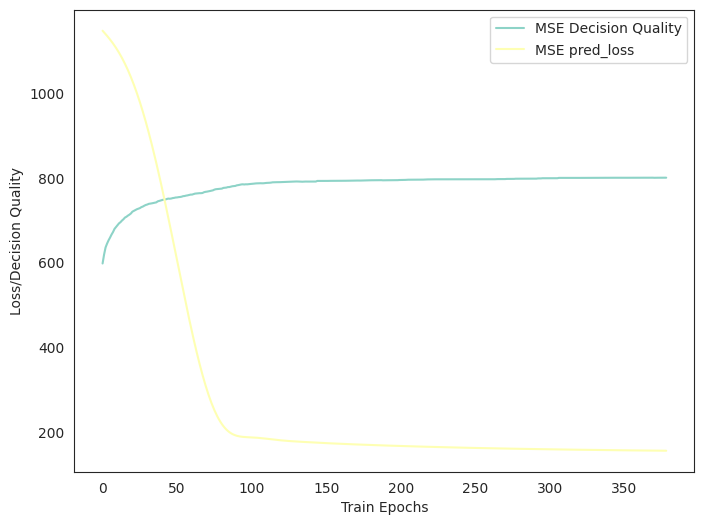

<Figure size 640x480 with 0 Axes>

In [14]:
draw_curve(mse_log, spo_log)

In [34]:
draw_curve(spo_log)

TypeError: draw_curve() missing 1 required positional argument: 'e2e_log'

In [35]:
spo_log.iloc[378]

epoch             Tr-378
obj              803.237
loss              101416
pred_loss    1.81904e+07
eval             61.2749
Name: 378, dtype: object